**Anime Data Pandas Project**

In [123]:
import numpy as np 
import pandas as pd 

In [124]:
df = pd.read_csv("anime.csv")

In [125]:
df.head(11)

,Rank,Title,Score
0,1,Fullmetal Alchemist: BrotherhoodTV (64 eps)Apr...,9.10
1,2,"Steins;GateTV (24 eps)Apr 2011 - Sep 20112,473...",9.07
2,3,Bleach: Sennen Kessen-henTV (13 eps)Oct 2022 -...,9.06
3,4,"Gintama°TV (51 eps)Apr 2015 - Mar 2016605,113 ...",9.06
4,5,Shingeki no Kyojin Season 3 Part 2TV (10 eps)A...,9.05
5,6,"Gintama'TV (51 eps)Apr 2011 - Mar 2012534,105 ...",9.04
6,7,Gintama: The FinalMovie (1 eps)Jan 2021 - Jan ...,9.04
7,8,Hunter x Hunter TV (148 eps)Oct 2011 - Sep 201...,9.04
8,9,Kaguya-sama wa Kokurasetai: Ultra RomanticTV (...,9.04
9,10,Gintama': EnchousenTV (13 eps)Oct 2012 - Mar 2...,9.03


**1 Extracting the Total Number of Episodes**

In [126]:
df.loc[1]["Title"]

'Steins;GateTV (24 eps)Apr 2011 - Sep 20112,473,707 members'

In [127]:
def extract_episodes(txt):
    check = False
    data = ""
    for i in txt:
        if i == ")":
            check = False
            return data
        if check == True: 
            data = data + i 
        if i == '(':
            check = True 

In [128]:
df["Episodes"] = df["Title"].apply(extract_episodes)

In [129]:
df.head(11)

,Rank,Title,Score,Episodes
0,1,Fullmetal Alchemist: BrotherhoodTV (64 eps)Apr...,9.10,64 eps
1,2,"Steins;GateTV (24 eps)Apr 2011 - Sep 20112,473...",9.07,24 eps
2,3,Bleach: Sennen Kessen-henTV (13 eps)Oct 2022 -...,9.06,13 eps
3,4,"Gintama°TV (51 eps)Apr 2015 - Mar 2016605,113 ...",9.06,51 eps
4,5,Shingeki no Kyojin Season 3 Part 2TV (10 eps)A...,9.05,10 eps
5,6,"Gintama'TV (51 eps)Apr 2011 - Mar 2012534,105 ...",9.04,51 eps
6,7,Gintama: The FinalMovie (1 eps)Jan 2021 - Jan ...,9.04,1 eps
7,8,Hunter x Hunter TV (148 eps)Oct 2011 - Sep 201...,9.04,148 eps
8,9,Kaguya-sama wa Kokurasetai: Ultra RomanticTV (...,9.04,13 eps
9,10,Gintama': EnchousenTV (13 eps)Oct 2012 - Mar 2...,9.03,13 eps


In [130]:
df['Episodes']= df['Episodes'].str.replace(" eps","")

In [131]:
df.head(11) 

,Rank,Title,Score,Episodes
0,1,Fullmetal Alchemist: BrotherhoodTV (64 eps)Apr...,9.10,64
1,2,"Steins;GateTV (24 eps)Apr 2011 - Sep 20112,473...",9.07,24
2,3,Bleach: Sennen Kessen-henTV (13 eps)Oct 2022 -...,9.06,13
3,4,"Gintama°TV (51 eps)Apr 2015 - Mar 2016605,113 ...",9.06,51
4,5,Shingeki no Kyojin Season 3 Part 2TV (10 eps)A...,9.05,10
5,6,"Gintama'TV (51 eps)Apr 2011 - Mar 2012534,105 ...",9.04,51
6,7,Gintama: The FinalMovie (1 eps)Jan 2021 - Jan ...,9.04,1
7,8,Hunter x Hunter TV (148 eps)Oct 2011 - Sep 201...,9.04,148
8,9,Kaguya-sama wa Kokurasetai: Ultra RomanticTV (...,9.04,13
9,10,Gintama': EnchousenTV (13 eps)Oct 2012 - Mar 2...,9.03,13


In [132]:
df['Episodes'] = df['Episodes'].astype(int)
df.head(1)

,Rank,Title,Score,Episodes
0,1,Fullmetal Alchemist: BrotherhoodTV (64 eps)Apr...,9.1,64


**2 Creating a New Column for Time Stamp**

In [133]:
df.loc[3]['Title']

'Gintama°TV (51 eps)Apr 2015 - Mar 2016605,113 members'

In [134]:
def extraction_time(txt):
    check = False
    data = ""
    for i in range(len(txt)):
        if txt[i] == ')':
            for j in range(i+1,i+20):
                data += txt[j]

            return data

In [135]:
df['Total Time'] = df['Title'].apply(extraction_time)
df.head(11)

,Rank,Title,Score,Episodes,Total Time
0,1,Fullmetal Alchemist: BrotherhoodTV (64 eps)Apr...,9.10,64,Apr 2009 - Jul 2010
1,2,"Steins;GateTV (24 eps)Apr 2011 - Sep 20112,473...",9.07,24,Apr 2011 - Sep 2011
2,3,Bleach: Sennen Kessen-henTV (13 eps)Oct 2022 -...,9.06,13,Oct 2022 - Dec 2022
3,4,"Gintama°TV (51 eps)Apr 2015 - Mar 2016605,113 ...",9.06,51,Apr 2015 - Mar 2016
4,5,Shingeki no Kyojin Season 3 Part 2TV (10 eps)A...,9.05,10,Apr 2019 - Jul 2019
5,6,"Gintama'TV (51 eps)Apr 2011 - Mar 2012534,105 ...",9.04,51,Apr 2011 - Mar 2012
6,7,Gintama: The FinalMovie (1 eps)Jan 2021 - Jan ...,9.04,1,Jan 2021 - Jan 2021
7,8,Hunter x Hunter TV (148 eps)Oct 2011 - Sep 201...,9.04,148,Oct 2011 - Sep 2014
8,9,Kaguya-sama wa Kokurasetai: Ultra RomanticTV (...,9.04,13,Apr 2022 - Jun 2022
9,10,Gintama': EnchousenTV (13 eps)Oct 2012 - Mar 2...,9.03,13,Oct 2012 - Mar 2013


In [136]:
from dateutil.relativedelta import relativedelta
from datetime import datetime

def calculate_total_months(period):
    try:
        start_str, end_str = period.split(' - ')

        start_date = datetime.strptime(start_str, '%b %Y')
        end_date = datetime.strptime(end_str, '%b %Y')

        r = relativedelta(end_date, start_date) 

        return r.years * 12 + r.months + 1

    except:
        return None

df['Months'] = df['Total Time'].apply(calculate_total_months)

In [137]:
df.head(2)

,Rank,Title,Score,Episodes,Total Time,Months
0,1,Fullmetal Alchemist: BrotherhoodTV (64 eps)Apr...,9.10,64,Apr 2009 - Jul 2010,16
1,2,"Steins;GateTV (24 eps)Apr 2011 - Sep 20112,473...",9.07,24,Apr 2011 - Sep 2011,6


**3 Which Anime Has the Highest Score**

In [138]:
df[df['Score'] == df['Score'].max()]

,Rank,Title,Score,Episodes,Total Time,Months
0,1,Fullmetal Alchemist: BrotherhoodTV (64 eps)Apr...,9.1,64,Apr 2009 - Jul 2010,16


In [139]:
df['Title'].head()

0    Fullmetal Alchemist: BrotherhoodTV (64 eps)Apr...
1    Steins;GateTV (24 eps)Apr 2011 - Sep 20112,473...
2    Bleach: Sennen Kessen-henTV (13 eps)Oct 2022 -...
3    Gintama°TV (51 eps)Apr 2015 - Mar 2016605,113 ...
4    Shingeki no Kyojin Season 3 Part 2TV (10 eps)A...
Name: Title, dtype: str

**4 Highest Episode Count**

In [140]:
df[df["Episodes"] == df["Episodes"].max()]

,Rank,Title,Score,Episodes,Total Time,Months
15,16,"GintamaTV (201 eps)Apr 2006 - Mar 20101,034,41...",8.94,201,Apr 2006 - Mar 2010,48


**5 Anime with top 5 episode count**

In [141]:
df.sort_values(by="Episodes", ascending=False).head(5)

,Rank,Title,Score,Episodes,Total Time,Months
15,16,"GintamaTV (201 eps)Apr 2006 - Mar 20101,034,41...",8.94,201,Apr 2006 - Mar 2010,48
7,8,Hunter x Hunter TV (148 eps)Oct 2011 - Sep 201...,9.04,148,Oct 2011 - Sep 2014,36
11,12,Ginga Eiyuu DensetsuOVA (110 eps)Jan 1988 - Ma...,9.02,110,Jan 1988 - Mar 1997,111
42,43,Hajime no IppoTV (75 eps)Oct 2000 - Mar 200255...,8.76,75,Oct 2000 - Mar 2002,18
24,25,"MonsterTV (74 eps)Apr 2004 - Sep 20051,041,081...",8.87,74,Apr 2004 - Sep 2005,18


**6 Give me top 5 highest scoring anime**

In [142]:
df.sort_values(by="Score", ascending=False).head(5)

,Rank,Title,Score,Episodes,Total Time,Months
0,1,Fullmetal Alchemist: BrotherhoodTV (64 eps)Apr...,9.10,64,Apr 2009 - Jul 2010,16
1,2,"Steins;GateTV (24 eps)Apr 2011 - Sep 20112,473...",9.07,24,Apr 2011 - Sep 2011,6
2,3,Bleach: Sennen Kessen-henTV (13 eps)Oct 2022 -...,9.06,13,Oct 2022 - Dec 2022,3
3,4,"Gintama°TV (51 eps)Apr 2015 - Mar 2016605,113 ...",9.06,51,Apr 2015 - Mar 2016,12
4,5,Shingeki no Kyojin Season 3 Part 2TV (10 eps)A...,9.05,10,Apr 2019 - Jul 2019,4


In [143]:
df.sort_values(by="Score", ascending=False).head(5)[["Title", "Score"]]

,Title,Score
0,Fullmetal Alchemist: BrotherhoodTV (64 eps)Apr...,9.10
1,"Steins;GateTV (24 eps)Apr 2011 - Sep 20112,473...",9.07
2,Bleach: Sennen Kessen-henTV (13 eps)Oct 2022 -...,9.06
3,"Gintama°TV (51 eps)Apr 2015 - Mar 2016605,113 ...",9.06
4,Shingeki no Kyojin Season 3 Part 2TV (10 eps)A...,9.05


**Which Is the Longest-Running Anime**

In [144]:
df[df["Months"] == df["Months"].max()]

,Rank,Title,Score,Episodes,Total Time,Months
11,12,Ginga Eiyuu DensetsuOVA (110 eps)Jan 1988 - Ma...,9.02,110,Jan 1988 - Mar 1997,111


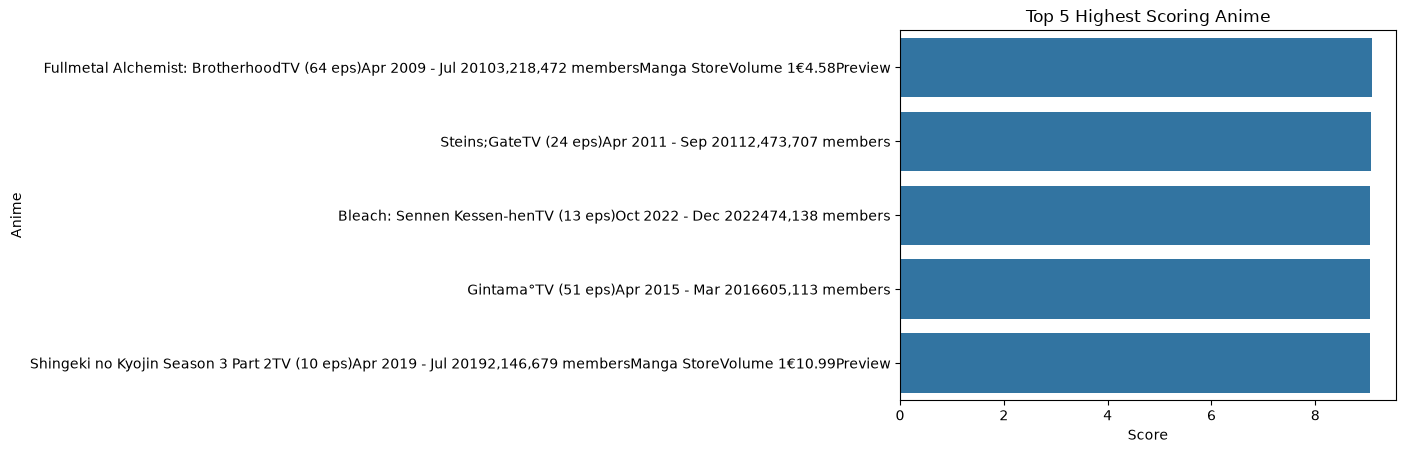

In [145]:
import matplotlib.pyplot as plt
import seaborn as sns

top5 = df.sort_values(by="Score", ascending=False).head(5)

sns.barplot(data=top5, x="Score", y="Title")

plt.title("Top 5 Highest Scoring Anime")
plt.xlabel("Score")
plt.ylabel("Anime")
plt.show()